In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import h5py
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

sys.path.insert(0, '/Users/ayman/Documents/GitHub/riesling/python')

import riesling as rlp

In [2]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

In [3]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


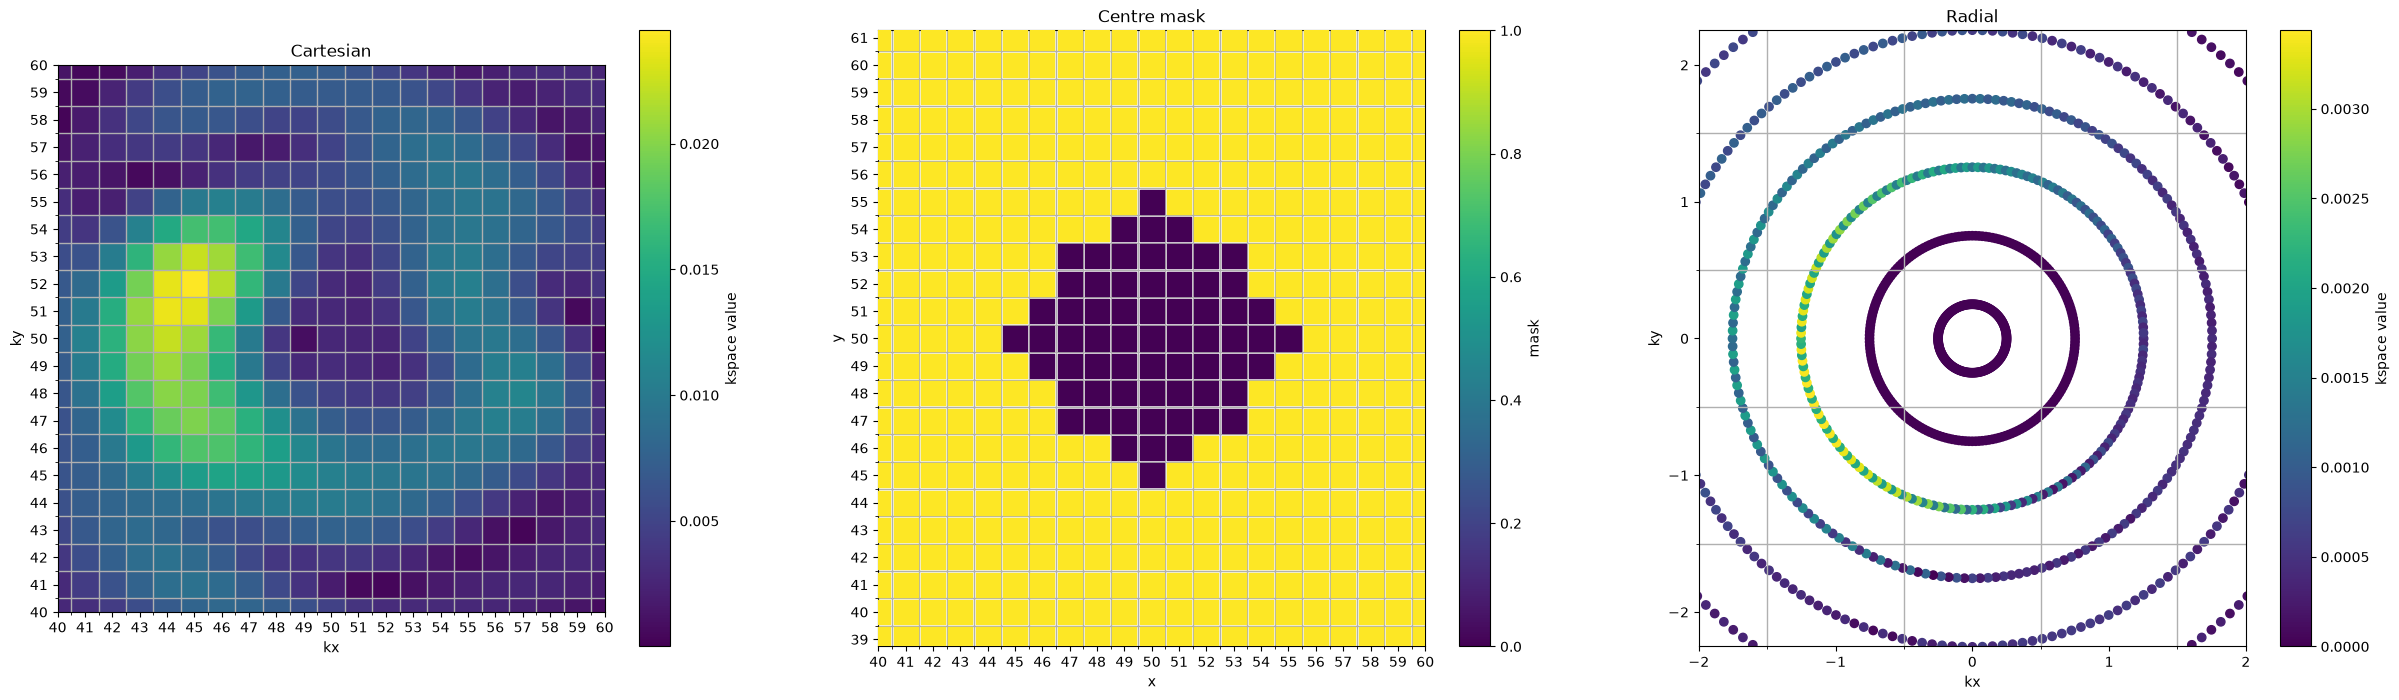

In [4]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4  # radius in pixels; adjust to cover the gap
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


asm.plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

In [5]:
def hankel_H_averaged_2(data_matrix, n_coils, Nx, Ny, w=5, s=2):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = (Nx - w) // s + 1
    n_win_y = (Ny - w) // s + 1

    for k in range(len(split_arr)):
        singlecol = split_arr[k]
        transposed = singlecol.T
        windows = []
        for j in range(len(transposed)):
            window = transposed[j].reshape(w,w)
            windows.append(window)
        windows_full = np.array(windows)
        
        recon = np.zeros((Nx, Ny), dtype=np.complex64)
        counts = np.zeros((Nx, Ny), dtype=np.float32)

        for index, win in enumerate(windows_full): 
            i = (index // n_win_y) * s
            j = (index % n_win_y) * s
            recon[i:i+w, j:j+w] += win
            counts[i:i+w, j:j+w] += 1

        counts[counts == 0] = 1
        recon = recon / counts
        kspace.append(recon.T)
    return np.array(kspace)


def hankel_2(kspace, w, s=2):
    x = 0
    y = 0
    c = 0
    N_x = (kspace.shape[1] - w) // s + 1
    N_y = (kspace.shape[2] - w) // s + 1
    N_c = kspace.shape[0]
    data_matrix = []
    for k in range(N_c):
        onecoil_matrix = np.empty((w*w, N_x*N_y), dtype=np.complex64)
        col_index = 0
        for i in range(N_y):
            for j in range(N_x):
                mat = kspace[c, x:x+w, y:y+w]
                col = mat.T.reshape(-1)
                onecoil_matrix[:, col_index] = col
                x += s
                col_index += 1
            x = 0
            y += s
        data_matrix.append(onecoil_matrix)
        y = 0
        c += 1
    return(np.vstack(data_matrix), N_c, N_x, N_y)

## Storing the inner kspace values to visualise convergence

1. At each iteration take the array and flatten
2. Take the square root of the sum of all the squared values and store
3. For each iteration, calculate the relative change by subtracting k from k-1 then dividing by k-1

Note:
1. Likely quicker to prebuild the df
2. Likely quicker to calculate

In [ ]:
#asm.plot_result(cartesian_zte, cartesian_kspace_rebuild, inner_region, post_loop_kspace, rank = 1, lamda=1)
plt.figure(figsize=(7.5,5))
plt.plot(deltas)
plt.title(f'Change across {num_iters} iterations')
plt.xlabel("iteration")
plt.ylabel("relative change")

In [6]:
def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask, stride):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    deltas = []
    k_prev = None
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_forhankel, w=window_size,s=stride)
        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H_averaged_2(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()

        vec = ksp_forhankel[:, ~dtg_mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    recombined = asm.jigsaw(output_kspace=output_kspace, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
    cartesian_kspace_rebuild = asm.zero_padding(recombined, 256,256)
    im_grid0 = sp.ifft(cartesian_kspace_rebuild, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5
    
    return(im_0, cartesian_kspace_rebuild, deltas)

In [ ]:
strides = [1,2,3,4,5,6]

num_iters = 50
window_size = 5
thresh = 0.2
cartesian_input = inner_region.copy()

results = {}
for stride_len in strides:
    im, cart, delta = LORAKS_loop(num_iters, window_size, thresh, cartesian_input, mask, stride_len)
    results[stride_len] = {'im': im, 'cart': cart, 'delta': delta}
    



In [144]:
def plotdiff(fig, index1, index2, imagearr, axname, numims, cmap='RdBu_r'):
    if not index2>numims-1:
        diff = (np.abs(np.abs(imagearr[index1]) - np.abs(imagearr[index2])))/ np.max(np.abs(imagearr[index1]))
        diff_plot = axname[index1, index2].imshow(diff, cmap)
        fig.colorbar(diff_plot, ax=axname[index1, index2], fraction=0.046, format='{x:.1%}')
    
def plotrowdiffs(fig, rownum, imagearr, axname, numims):
    for jj in range(numims):
        if not rownum == rownum+jj:
            plotdiff(fig,rownum, rownum+jj,imagearr, axname, numims)

def diff_matrix(imdict):
    titles, imarray = list(imdict.keys()), list(imdict.values())
    n = len(imarray)
    n = len(imarray)
    fig, axs = plt.subplots(n, n, figsize=(4*n, 4*n))
    for i in range(n):
        for j in range(n):
            axs[i, j].axis('off')
        im = axs[i,i].imshow(np.abs(imarray[i]), cmap='gray')
        axs[i, i].set_title(f'{titles[i]}')
        fig.colorbar(im,ax=axs[i,i], fraction=0.046)
    for ii in range(n):
        plotrowdiffs(fig, ii, imarray, axs, n)

    plt.tight_layout()
    plt.show()

In [122]:
ims = {f'stride {s}': results[s]['im'] for s in results}

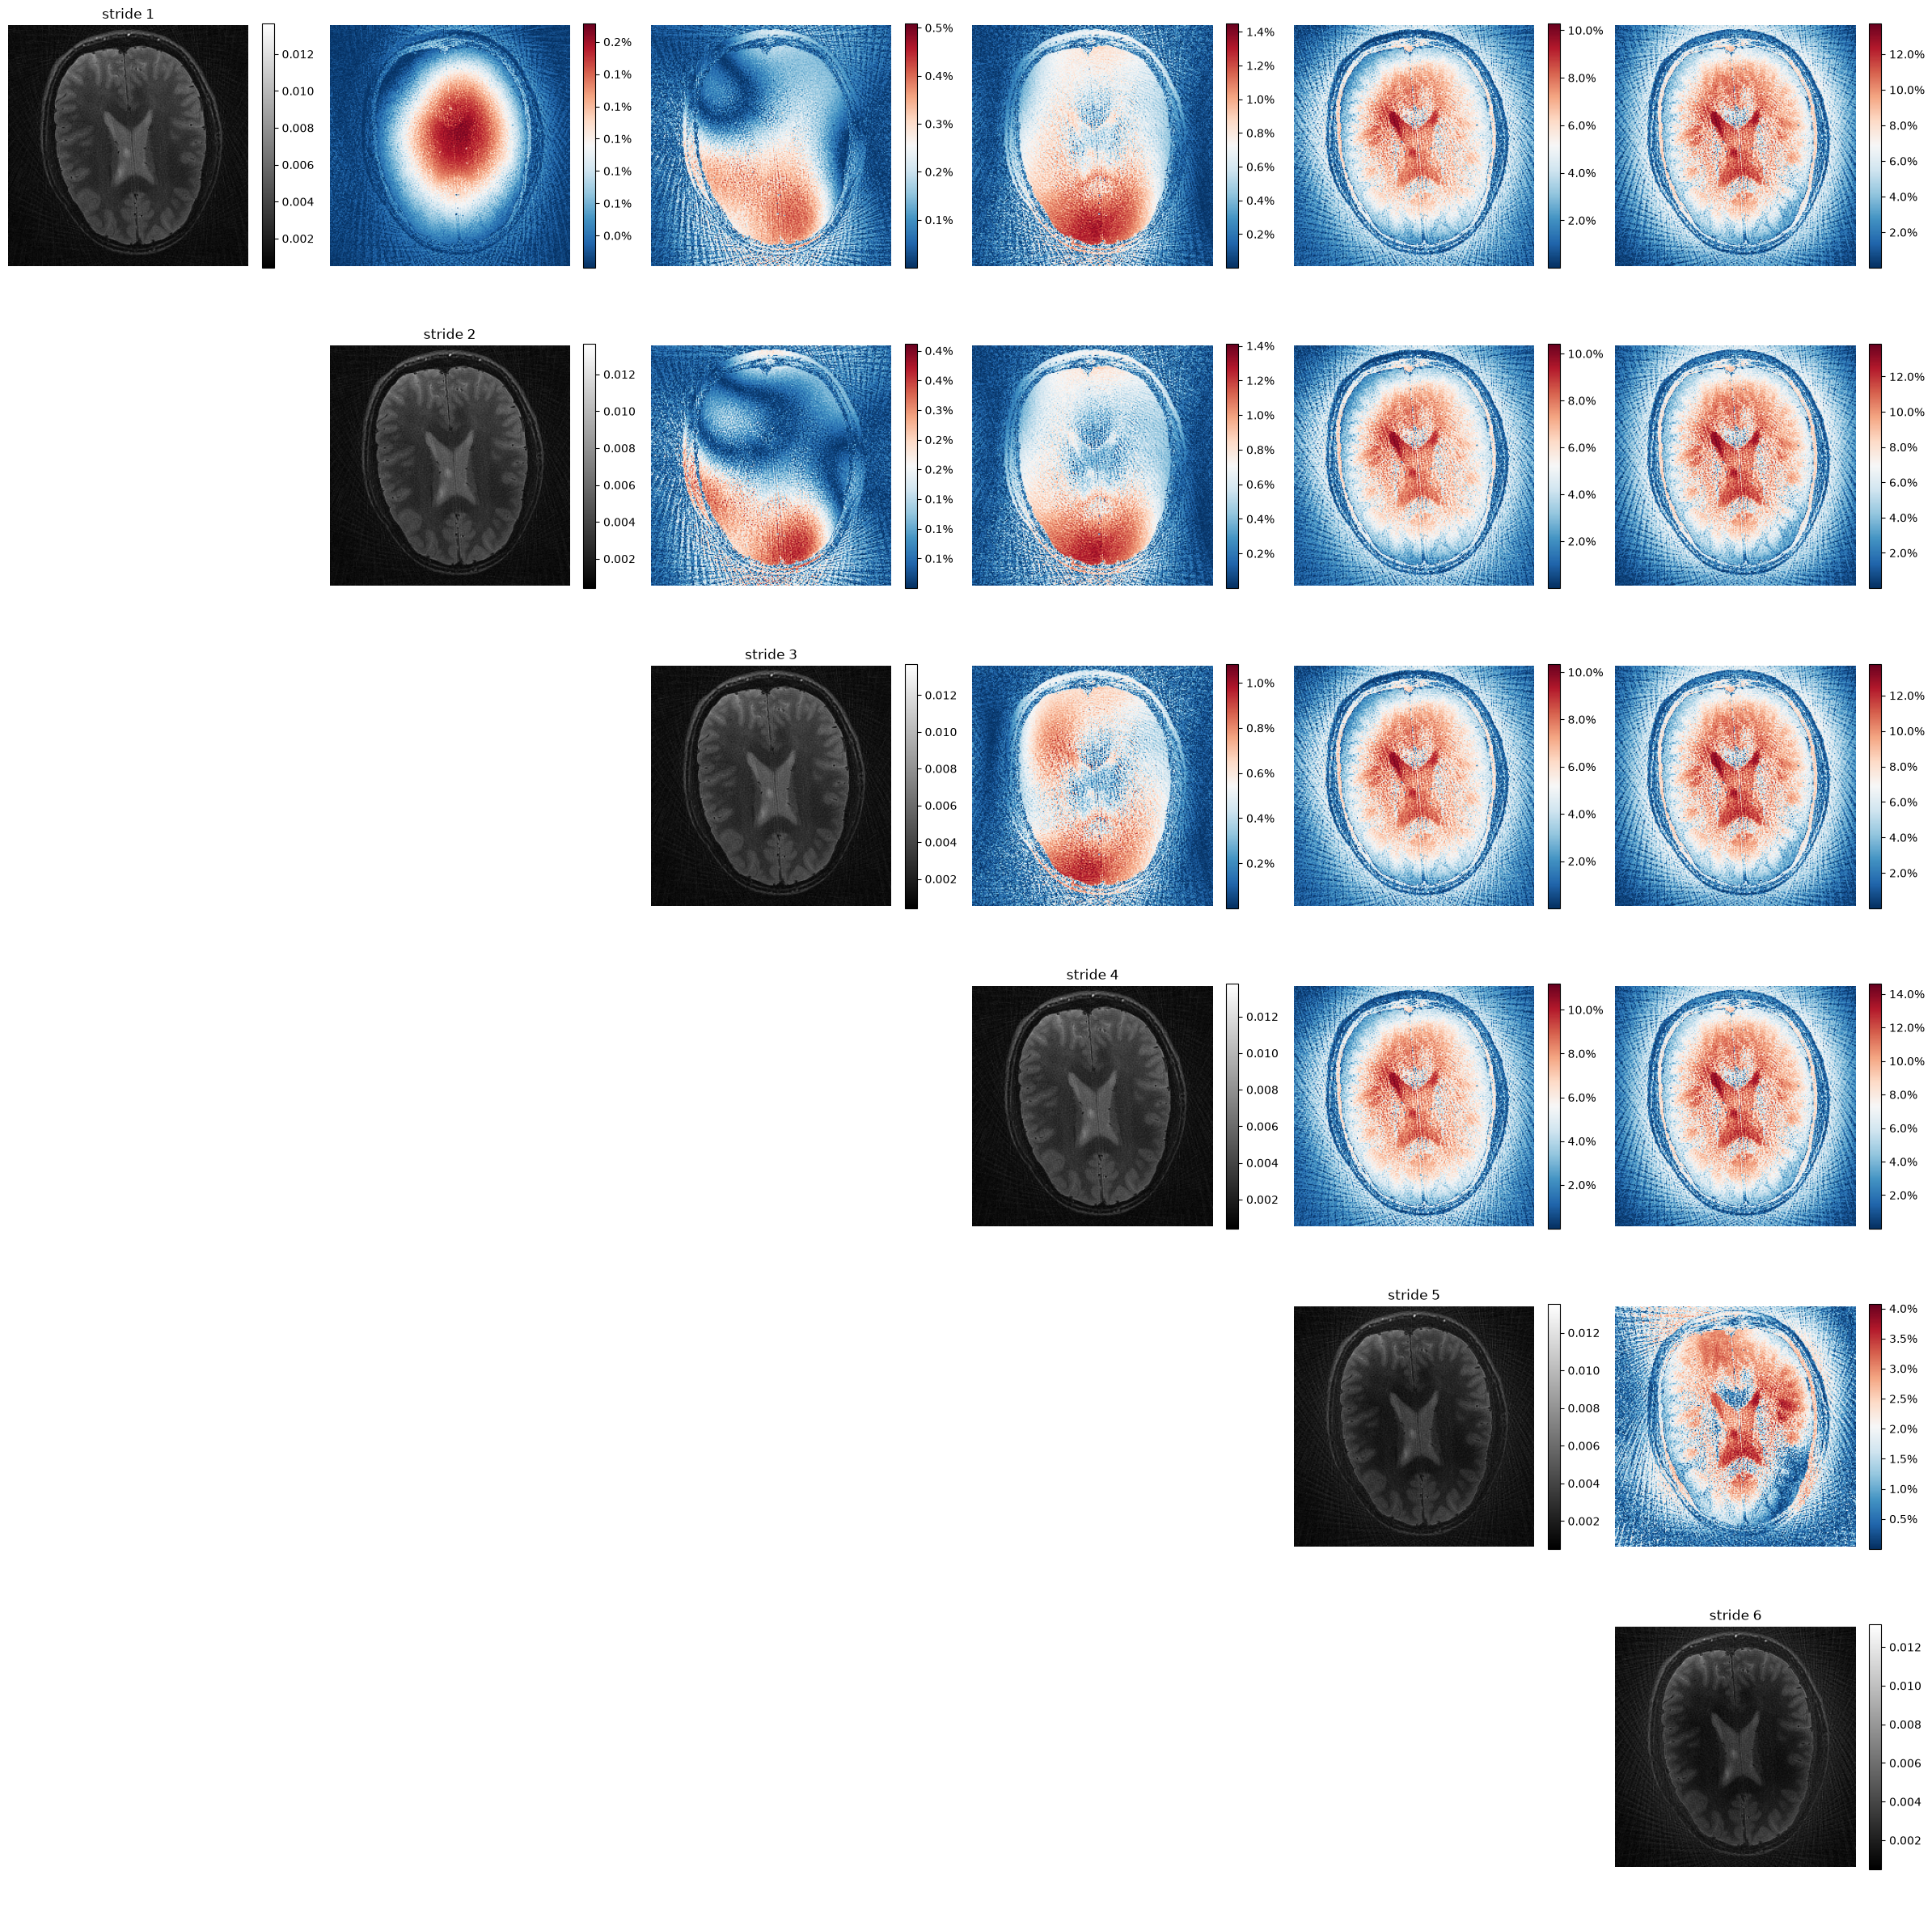

In [147]:
diff_matrix(ims)

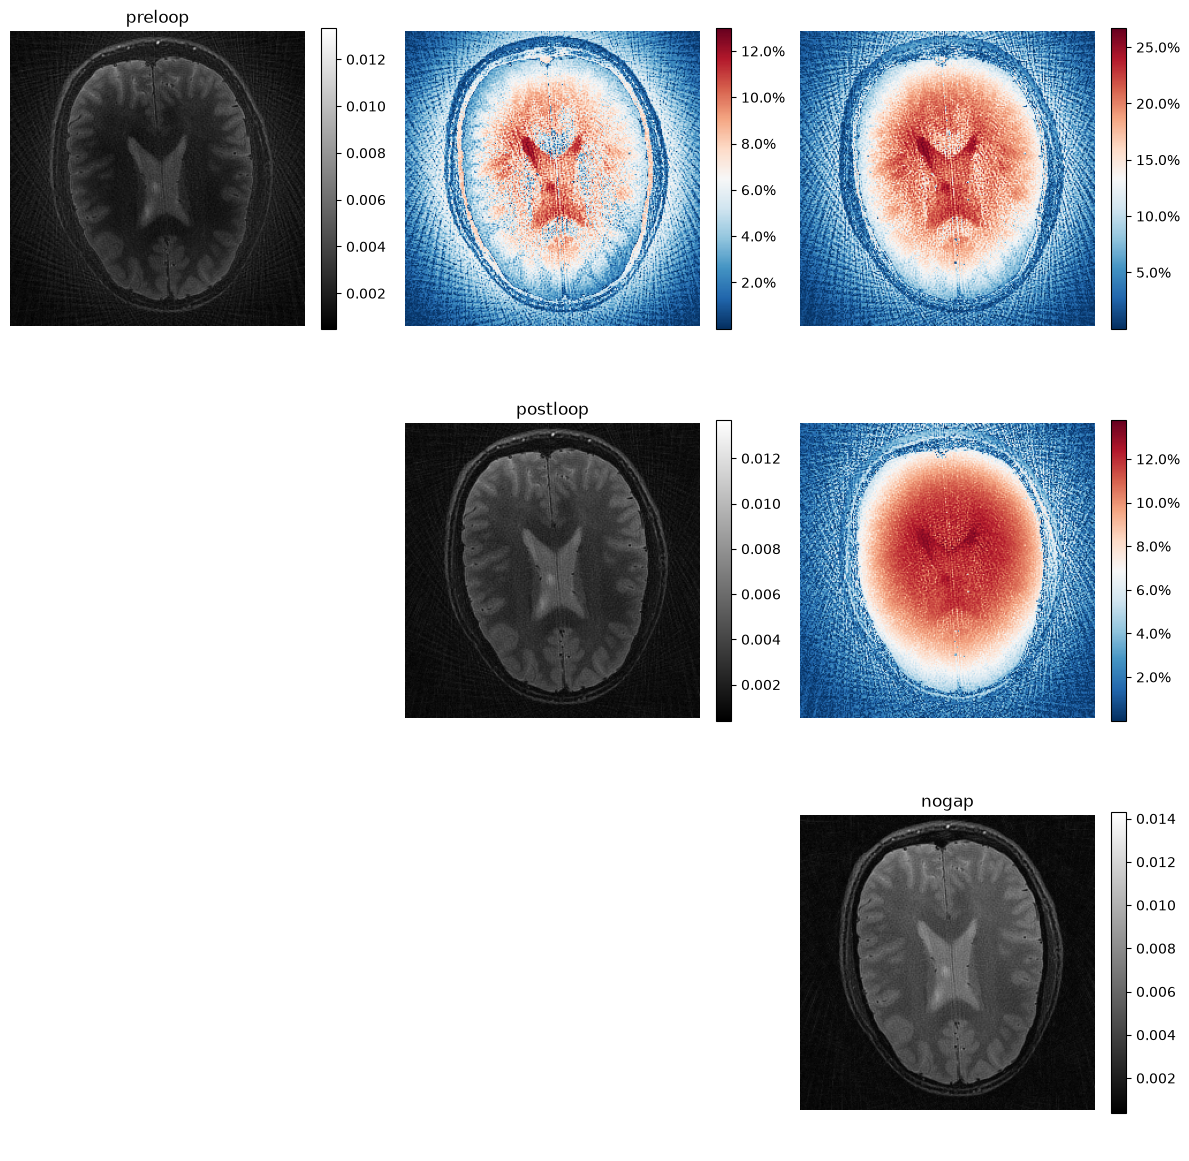

In [157]:
im_grid0 = sp.ifft(cartesian_zte, axes=(-2, -1))
preloop = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

cartesian_kspace_rebuild = ims['stride 1']
zte_radial_kspace1, zte_radial_coords1 = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)
dcf1 = (zte_radial_coords1[...,0]**2 + zte_radial_coords1[...,1]**2)**0.5
im_grid3 = sp.nufft_adjoint(zte_radial_kspace1* dcf1, zte_radial_coords1)
img_3 = np.sum(np.abs(im_grid3)**2, axis=0)**0.5

test_results = {'preloop':im_0, 'postloop':cartesian_kspace_rebuild, 'nogap':img_3}

diff_matrix(test_results)